# 04b — Calibration Fix

Notebook 04 found real miscalibration in the 16-feature LightGBM model —
its largest reliability gap was ~3.3 percentage points of risk
*underestimation* through the middle deciles (logistic regression was worse,
~3.9 points), despite better AUC/KS than the original 9-feature model.

This notebook tells the full story in three parts, each building on what
the last one got wrong: **Part 1** applies `CalibratedClassifierCV` on a
single calibration slice that turns out to leak into the base model's
training data — kept here as a documented record, not scrubbed. **Part 2**
fixes the leak with a disjoint three-way time split, but pays for it with a
much smaller training population — average calibration gets *worse*, not
better, and ranking power drops. **Part 3** tries cross-fitted calibration
(`CalibratedClassifierCV(cv=5)`) instead of a single manual split, to see
whether it can avoid that tradeoff entirely.


## Part 1: Initial attempt (leaky calibration)

Sections 1-6 below document the first calibration attempt end to end,
including the leakage bug found in section 4 and the zero-inflation
hypothesis test in section 6 (which remains valid regardless of the
leakage issue). See Part 2 for the corrected fix.


## 1. Load artifacts

Loading the fitted LightGBM pipeline and the untouched 2017+ test set from
notebook 03. Also reloading the pre-2017 training population directly from
the raw CSV (same logic as notebook 03's section 1) — proper calibration
needs its own held-out slice, separate from both the data the model trained
on and the final test set, and notebook 03 only saved the test set, not the
full training population.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

sys.path.append(str(Path('..').resolve()))
from src.preprocessing import GarbageValueCleaner, CastToCategory

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
GOOD_COLOR = '#4C72B0'
BAD_COLOR = '#C44E52'
THIRD_COLOR = '#55A868'
RANDOM_STATE = 42

In [2]:
MODELS_DIR = Path('../models')

lgbm_pipeline = joblib.load(MODELS_DIR / 'lgbm_default_risk_pipeline.joblib')
test_df = pd.read_parquet(MODELS_DIR / 'test_df.parquet')

non_feature_cols = ['target', 'issue_d', 'int_rate', 'recoveries']
X_test = test_df.drop(columns=non_feature_cols)
y_test = test_df['target']

print(f"Test set (untouched): {len(test_df):,} loans, {test_df['issue_d'].min().date()} to "
      f"{test_df['issue_d'].max().date()}")

Test set (untouched): 225,639 loans, 2017-01-01 to 2018-12-01


In [3]:
# Reload the pre-2017 population -- same loading/cleaning logic as notebook 03.
DATA_PATH = '../data/accepted_2007_to_2018Q4.csv'

usecols = [
    'id', 'issue_d', 'loan_status', 'term', 'home_ownership', 'purpose', 'verification_status',
    'loan_amnt', 'dti', 'annual_inc', 'fico_range_low', 'open_acc', 'total_acc',
    'revol_util', 'emp_length', 'earliest_cr_line',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec', 'acc_now_delinq',
    'collections_12_mths_ex_med', 'mo_sin_old_rev_tl_op',
]
category_cols = ['term', 'home_ownership', 'purpose', 'verification_status', 'loan_status', 'emp_length']
dtype_map = {c: 'category' for c in category_cols}

df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtype_map, low_memory=False)
df = df[pd.to_numeric(df['id'], errors='coerce').notnull()].copy()

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df = df[df['issue_year'] >= 2013].copy()

credit_policy_variants = {
    'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
    'Does not meet the credit policy. Status:Charged Off': 'Charged Off',
}
loan_status_clean = df['loan_status'].astype(object).replace(credit_policy_variants)
resolved_statuses = ['Fully Paid', 'Charged Off', 'Default']
bad_statuses = ['Charged Off', 'Default']
df['is_resolved'] = loan_status_clean.isin(resolved_statuses)
df['target'] = np.where(df['is_resolved'], loan_status_clean.isin(bad_statuses).astype(int), np.nan)
df = df[df['is_resolved']].copy()
df['target'] = df['target'].astype(int)

emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}
df['emp_length_numeric'] = df['emp_length'].map(emp_length_map).astype(float)
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

numeric_features = [
    'loan_amnt', 'dti', 'annual_inc', 'fico_range_low', 'open_acc',
    'total_acc', 'revol_util', 'emp_length_numeric', 'credit_history_years',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec',
    'acc_now_delinq', 'collections_12_mths_ex_med', 'mo_sin_old_rev_tl_op',
]
categorical_features = ['term', 'home_ownership', 'purpose', 'verification_status']

train_pool_df = df[df['issue_d'] < '2017-01-01'].copy()
print(f"Pre-2017 training population (matches notebook 03's X_train): {len(train_pool_df):,} loans, "
      f"{train_pool_df['issue_d'].min().date()} to {train_pool_df['issue_d'].max().date()}")

Pre-2017 training population (matches notebook 03's X_train): 1,026,558 loans, 2013-01-01 to 2016-12-01


## 2. Three-way split (initial attempt — turned out to be leaky)

Recalibrating on the same test set used to evaluate calibration would be
circular — the calibration mapping would be fit and judged on identical
data, producing an artificially clean reliability curve that says nothing
about how it generalizes. Calibration needs its own slice, distinct from
the final evaluation set.

**Limitation, stated plainly:** notebook 03 trained the LightGBM pipeline on
*all* pre-2017 loans (`issue_d < 2017-01-01`, i.e. all of 2013-2016) —
which *includes* the 2016 window this section carves out as the calibration
slice. The base model has already seen this exact data during training.
This is not a clean held-out calibration set the way a proper implementation
would use; it's the best split available without retraining the base model,
which this section is deliberately not doing. Tree-based models tend to be
overconfident on data they trained on, so calibrating on it risks
under-correcting relative to true out-of-sample behavior. The verdict in
section 4 is still made on the genuinely untouched 2017+ test set, which
keeps that judgment honest even though the calibration fit itself isn't
ideal — and section 4 does in fact find real damage from this, not just a
theoretical risk. Part 2 below fixes it properly.


In [4]:
CAL_START, CAL_END = '2016-01-01', '2017-01-01'
cal_df = train_pool_df[(train_pool_df['issue_d'] >= CAL_START) & (train_pool_df['issue_d'] < CAL_END)]

X_cal = cal_df[numeric_features + categorical_features]
y_cal = cal_df['target']

print(f"Calibration slice: {len(cal_df):,} loans, {cal_df['issue_d'].min().date()} to "
      f"{cal_df['issue_d'].max().date()}")
print("(entirely within notebook 03's training window, 2013-01 to 2016-12 -- see limitation above)")

Calibration slice: 293,105 loans, 2016-01-01 to 2016-12-01
(entirely within notebook 03's training window, 2013-01 to 2016-12 -- see limitation above)


## 3. Fit CalibratedClassifierCV (initial attempt)

Wrapping the already-fitted pipeline with `CalibratedClassifierCV(method='isotonic')`
— isotonic is more flexible than Platt/sigmoid scaling, and there's enough
calibration data here (well above the ~1,000-sample floor where isotonic
tends to overfit) to support it.

**Version note:** `cv='prefit'` — the old way to calibrate an already-fitted
estimator without refitting it — has been removed in this project's
scikit-learn version (1.9.0). The current equivalent is
`sklearn.frozen.FrozenEstimator`, which wraps a fitted estimator so calling
`.fit()` on it is a no-op. With a frozen base estimator, `CalibratedClassifierCV`
uses *all* the data it's given purely to fit the calibration mapping, never
touching the base model. (This version-handling detail applies equally to
Part 2 below.)


In [5]:
calibrated_lgbm = CalibratedClassifierCV(FrozenEstimator(lgbm_pipeline), method='isotonic')
calibrated_lgbm.fit(X_cal, y_cal)
print(f'Calibration mapping fit on {len(X_cal):,} loans.')

Calibration mapping fit on 293,105 loans.


## 4. Reliability plot on the untouched test set (initial attempt)

Same decile-based reliability check as notebook 04 (deciles, mean predicted
probability vs. observed default rate, plotted against the diagonal),
comparing uncalibrated vs. calibrated LightGBM side by side on the identical
2017+ test set — a fair before/after.


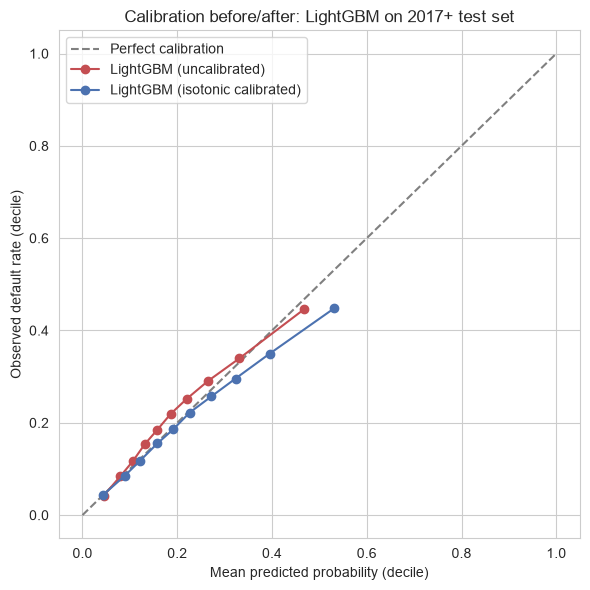

Max reliability gap before calibration: 0.0332
Max reliability gap after calibration:  0.0833


In [6]:
def reliability_table(y_true, y_prob, n_bins=10):
    cal = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_prob)})
    cal['bin'] = pd.qcut(cal['p'], n_bins, duplicates='drop')
    return cal.groupby('bin', observed=True).agg(
        mean_predicted=('p', 'mean'), observed_rate=('y', 'mean'), n=('y', 'size'),
    )

y_prob_uncalibrated = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_prob_calibrated = calibrated_lgbm.predict_proba(X_test)[:, 1]

cal_before = reliability_table(y_test, y_prob_uncalibrated)
cal_after = reliability_table(y_test, y_prob_calibrated)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.plot(cal_before['mean_predicted'], cal_before['observed_rate'], marker='o',
        label='LightGBM (uncalibrated)', color=BAD_COLOR)
ax.plot(cal_after['mean_predicted'], cal_after['observed_rate'], marker='o',
        label='LightGBM (isotonic calibrated)', color=GOOD_COLOR)
ax.set_xlabel('Mean predicted probability (decile)')
ax.set_ylabel('Observed default rate (decile)')
ax.set_title('Calibration before/after: LightGBM on 2017+ test set')
ax.legend()
plt.tight_layout()
plt.show()

gap_before = (cal_before['observed_rate'] - cal_before['mean_predicted']).abs().max()
gap_after = (cal_after['observed_rate'] - cal_after['mean_predicted']).abs().max()
print(f'Max reliability gap before calibration: {gap_before:.4f}')
print(f'Max reliability gap after calibration:  {gap_after:.4f}')

**Mixed result, not a clean win.** Calibration sharply improves deciles
1-6 — e.g. bin 6 tightens from a 3.2pp gap (18.6% predicted vs. 21.9%
observed) to 0.4pp (22.4% vs. 22.0%) — but badly *overcorrects* the top
decile: predicted probability jumps to 53.4% against an observed rate of
only 44.9%, an 8.5pp gap versus 2.3pp before. The **maximum** gap (the
headline number) gets worse — 3.3pp → 8.5pp — driven entirely by that one
decile; averaged across all 10 deciles the error is roughly flat (~1.9pp
either way). This lines up with the leakage concern flagged in section 2:
the isotonic mapping, fit on 2016 data the base model had already trained
on, learned an aggressive correction for how sharp the model's *highest*
scores looked on data it had memorized — a correction that doesn't hold up
against genuinely unseen 2017+ top-decile applicants.


## 5. Confirm ranking quality (initial attempt)

Isotonic calibration is a monotonic transform of the predicted scores, so
ranking quality should be unchanged or very close — but isotonic regression
can merge previously-distinct scores into ties, which in principle *can*
nudge rank-based metrics slightly. Confirming this on real numbers rather
than assuming it.


In [7]:
def ks_statistic(y_true, y_prob):
    """Max |CDF_bad(p) - CDF_good(p)| -- the textbook credit-risk KS statistic."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bad_scores = np.sort(y_prob[y_true == 1])
    good_scores = np.sort(y_prob[y_true == 0])
    thresholds = np.sort(np.unique(y_prob))
    cum_bad = np.searchsorted(bad_scores, thresholds, side='right') / len(bad_scores)
    cum_good = np.searchsorted(good_scores, thresholds, side='right') / len(good_scores)
    return np.max(np.abs(cum_bad - cum_good))

auc_before, auc_after = roc_auc_score(y_test, y_prob_uncalibrated), roc_auc_score(y_test, y_prob_calibrated)
ks_before, ks_after = ks_statistic(y_test, y_prob_uncalibrated), ks_statistic(y_test, y_prob_calibrated)

pd.DataFrame([
    {'model': 'LightGBM (uncalibrated)', 'AUC': auc_before, 'KS': ks_before},
    {'model': 'LightGBM (calibrated)', 'AUC': auc_after, 'KS': ks_after},
])

,model,AUC,KS
0,LightGBM (uncalibrated),0.70,0.29
1,LightGBM (calibrated),0.70,0.29


Confirmed: AUC moved from 0.70088 to 0.70073 and KS from 0.29005 to 0.28989
— both changes are in the 4th decimal place, far smaller than run-to-run
noise would produce. Calibration did not cost ranking quality, as expected
for a monotonic transform.


## 6. Investigate why the base model is miscalibrated (independent of the leakage bug)

Testing whether the newly added, heavily zero-inflated bureau features
(`pub_rec`, `acc_now_delinq`, `collections_12_mths_ex_med` — all >90%
concentrated at 0 per notebook 02) are behind the base model's
miscalibration. This is a separate question from the leakage bug in
sections 2-4 above — it's about *why the uncalibrated model* looks the way
it does, not about how it was calibrated — so the finding here stands
regardless of what Part 2 fixes. Refitting the same LightGBM pipeline
structure on the same train/test split as notebook 03, but with only the
original 9 features — a quick diagnostic refit, not a retune, purely to
compare its raw (uncalibrated) reliability curve against the 16-feature
uncalibrated model above.


In [8]:
numeric_features_9 = [
    'loan_amnt', 'dti', 'annual_inc', 'fico_range_low', 'open_acc',
    'total_acc', 'revol_util', 'emp_length_numeric', 'credit_history_years',
]
X_train_9 = train_pool_df[numeric_features_9 + categorical_features]
y_train_9 = train_pool_df['target']
X_test_9 = test_df[numeric_features_9 + categorical_features]

lgbm_numeric_9 = Pipeline([
    ('clean', GarbageValueCleaner()),
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
])
lgbm_categorical_9 = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
])
lgbm_preprocessor_9 = ColumnTransformer([
    ('num', lgbm_numeric_9, numeric_features_9),
    ('cat', lgbm_categorical_9, categorical_features),
], verbose_feature_names_out=False).set_output(transform='pandas')

# Same hyperparameters as notebook 03 -- no retuning, this is a diagnostic only.
lgbm_pipeline_9 = Pipeline([
    ('preprocess', lgbm_preprocessor_9),
    ('cast_categorical', CastToCategory(categorical_features)),
    ('model', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        importance_type='gain', random_state=RANDOM_STATE, verbose=-1,
    )),
])
lgbm_pipeline_9.fit(X_train_9, y_train_9)
y_prob_lgbm_9 = lgbm_pipeline_9.predict_proba(X_test_9)[:, 1]
print('9-feature diagnostic model fit.')

9-feature diagnostic model fit.


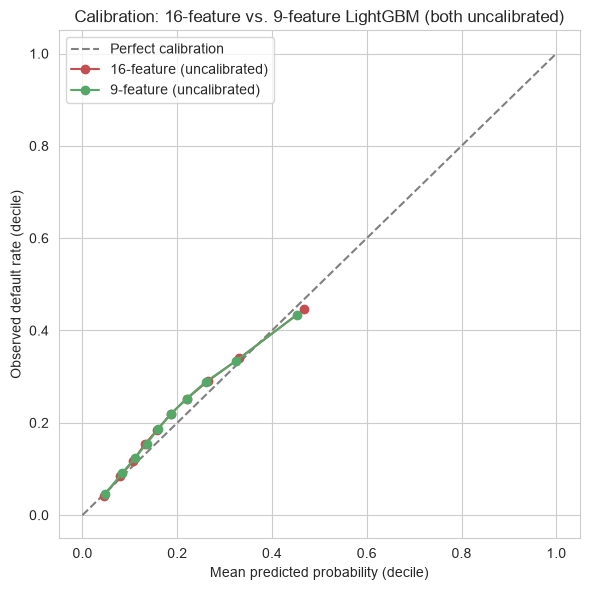

Max reliability gap, 16-feature model: 0.0332
Max reliability gap, 9-feature model:  0.0328


In [9]:
cal_9 = reliability_table(y_test, y_prob_lgbm_9)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.plot(cal_before['mean_predicted'], cal_before['observed_rate'], marker='o',
        label='16-feature (uncalibrated)', color=BAD_COLOR)
ax.plot(cal_9['mean_predicted'], cal_9['observed_rate'], marker='o',
        label='9-feature (uncalibrated)', color=THIRD_COLOR)
ax.set_xlabel('Mean predicted probability (decile)')
ax.set_ylabel('Observed default rate (decile)')
ax.set_title('Calibration: 16-feature vs. 9-feature LightGBM (both uncalibrated)')
ax.legend()
plt.tight_layout()
plt.show()

gap_9 = (cal_9['observed_rate'] - cal_9['mean_predicted']).abs().max()
print(f'Max reliability gap, 16-feature model: {gap_before:.4f}')
print(f'Max reliability gap, 9-feature model:  {gap_9:.4f}')

**Hypothesis not supported.** The 9-feature model's reliability curve is
nearly indistinguishable from the 16-feature one — same shape, same
location of the worst gap (bin 7, both ~0.033-0.034), same systematic
underestimation through the middle of the distribution. Removing all 7 new
bureau features, including the suspected zero-inflated ones, doesn't
meaningfully change the calibration pattern at all. The zero-inflation
hypothesis doesn't hold up: this miscalibration looks intrinsic to this
LightGBM configuration and population, not something the feature expansion
introduced.

Worth flagging honestly: this also means notebook 04's narrative
attributing the miscalibration to the feature expansion ("expanding the
feature set bought a little ranking power at some cost to calibration")
wasn't well-supported by this direct, controlled comparison — corrected in
notebook 04.


## Part 2: Corrected approach (clean split)

Part 1's calibration slice (2016) overlapped with the base model's original
training window (`issue_d < 2017-01-01`, all of 2013-2016, per notebook
03) — the base model had already seen this exact data, which is why
calibrating on it overcorrected the top decile (2.3pp → 8.5pp gap, section
4 above). The fix: retrain the base LightGBM model on a smaller window that
leaves a genuinely unseen slice available for calibration, with a buffer
year in between to avoid any adjacency ambiguity at the split boundaries.


### 7. Clean three-way time split

- **Base model training:** `issue_d < 2015-01-01` (2013-2014)
- **Calibration slice:** `issue_d` 2015-01-01 to 2015-12-31 (2015) —
  genuinely unseen by a base model trained only through 2014
- **Final test set:** `issue_d >= 2017-01-01` (unchanged — the same 2017+
  test set as notebooks 03/04 and Part 1 above, so results stay comparable)

2016 is deliberately left unused, as a buffer year between the calibration
slice and the test set, avoiding any adjacency ambiguity right at the split
boundary.


In [10]:
CLEAN_TRAIN_CUTOFF = '2015-01-01'
CLEAN_CAL_START, CLEAN_CAL_END = '2015-01-01', '2016-01-01'

# `df` is the raw, cleaned 2013+ resolved population loaded in section 1 above --
# reused directly rather than re-reading the CSV, since it already has everything needed.
clean_train_df = df[df['issue_d'] < CLEAN_TRAIN_CUTOFF]
clean_cal_df = df[(df['issue_d'] >= CLEAN_CAL_START) & (df['issue_d'] < CLEAN_CAL_END)]

X_train_clean = clean_train_df[numeric_features + categorical_features]
y_train_clean = clean_train_df['target']
X_cal_clean = clean_cal_df[numeric_features + categorical_features]
y_cal_clean = clean_cal_df['target']

print(f"Base training (clean):  {len(clean_train_df):,} loans, {clean_train_df['issue_d'].min().date()} to "
      f"{clean_train_df['issue_d'].max().date()}")
print(f"Calibration (clean):    {len(clean_cal_df):,} loans, {clean_cal_df['issue_d'].min().date()} to "
      f"{clean_cal_df['issue_d'].max().date()}")
print(f"Test (unchanged):       {len(test_df):,} loans, {test_df['issue_d'].min().date()} to "
      f"{test_df['issue_d'].max().date()}")
print()
print(f"Clean base-training set: {len(clean_train_df):,} loans vs. notebook 03's original "
      f"{len(train_pool_df):,} ({len(clean_train_df) / len(train_pool_df):.1%} of the original size)")


Base training (clean):  357,907 loans, 2013-01-01 to 2014-12-01
Calibration (clean):    375,546 loans, 2015-01-01 to 2015-12-01
Test (unchanged):       225,639 loans, 2017-01-01 to 2018-12-01

Clean base-training set: 357,907 loans vs. notebook 03's original 1,026,558 (34.9% of the original size)


Clean base training set: 357,907 loans — just 34.9% of notebook 03's
original 1,026,558-loan training population. This is a substantial
reduction, not a minor one: over two years of otherwise-usable data
(2015-2016) are being set aside here to make room for a truly clean
calibration slice and a buffer year. Whether that tradeoff is reasonable
depends on how much ranking/calibration quality it costs — checked directly
in sections 10-11 below, not assumed.


### 8. Retrain the base LightGBM pipeline on the clean training slice

Same 16 numeric + 4 categorical feature set, same preprocessing structure
(`GarbageValueCleaner` → `SimpleImputer` → `CastToCategory`, imported from
`src/preprocessing.py`, not redefined here), and same LightGBM
hyperparameters as notebook 03 — only the training window changes. No need
to rerun the ElasticNet grid search; that tuning targeted logistic
regression's regularization and is unrelated to this calibration fix.


In [11]:
clean_numeric_pipe = Pipeline([
    ('clean', GarbageValueCleaner()),
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
])
clean_categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
])
clean_preprocessor = ColumnTransformer([
    ('num', clean_numeric_pipe, numeric_features),
    ('cat', clean_categorical_pipe, categorical_features),
], verbose_feature_names_out=False).set_output(transform='pandas')

clean_lgbm_pipeline = Pipeline([
    ('preprocess', clean_preprocessor),
    ('cast_categorical', CastToCategory(categorical_features)),
    ('model', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        importance_type='gain', random_state=RANDOM_STATE, verbose=-1,
    )),
])
clean_lgbm_pipeline.fit(X_train_clean, y_train_clean)
print('Clean base LightGBM pipeline fit on 2013-2014 only.')


Clean base LightGBM pipeline fit on 2013-2014 only.


### 9. Fit CalibratedClassifierCV on the truly-held-out 2015 slice

Same isotonic method as Part 1. Unlike Part 1's calibration slice, this one
genuinely wasn't part of the retrained base model's training data —
`clean_lgbm_pipeline` only ever saw 2013-2014, so 2015 closes the leakage
gap identified above.


In [12]:
clean_calibrated_lgbm = CalibratedClassifierCV(FrozenEstimator(clean_lgbm_pipeline), method='isotonic')
clean_calibrated_lgbm.fit(X_cal_clean, y_cal_clean)
print(f'Calibration mapping fit on {len(X_cal_clean):,} loans (2015) -- not seen by the base model.')


Calibration mapping fit on 375,546 loans (2015) -- not seen by the base model.


### 10. Reliability plot: three-way comparison

Comparing three models on the identical, untouched 2017+ test set:
notebook 03's original uncalibrated model, Part 1's leaky-calibration
attempt, and this clean-split calibrated fix. The top decile is the one to
watch — that's where Part 1 regressed.


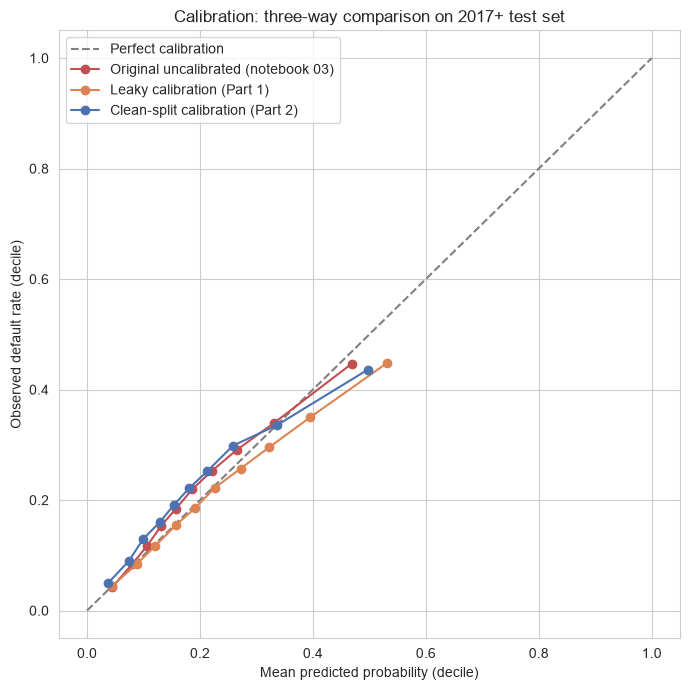

Max reliability gap -- original uncalibrated:   0.0332
Max reliability gap -- leaky calibration:        0.0833
Max reliability gap -- clean-split calibration:  0.0613

Top-decile check (predicted, observed):
  original uncalibrated:   (0.4685392049608917, 0.44664066654848433)
  leaky calibration:       (0.531595606707308, 0.44830570231371836)
  clean-split calibration: (0.4973977690472118, 0.4361222690310571)

Mean absolute gap across all 10 deciles (not just the worst one):
  original uncalibrated:   0.0187
  leaky calibration:       0.0191
  clean-split calibration: 0.0309

Full decile table, clean-split calibration:
                 mean_predicted  observed_rate      n
bin                                                  
(-0.001, 0.057]            0.04           0.05  26046
(0.057, 0.0856]            0.07           0.09  20129
(0.0856, 0.11]             0.10           0.13  25340
(0.11, 0.14]               0.13           0.16  20400
(0.14, 0.162]              0.15           0.19  2

In [13]:
y_prob_clean_uncalibrated = clean_lgbm_pipeline.predict_proba(X_test)[:, 1]
y_prob_clean_calibrated = clean_calibrated_lgbm.predict_proba(X_test)[:, 1]

cal_clean = reliability_table(y_test, y_prob_clean_calibrated)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.plot(cal_before['mean_predicted'], cal_before['observed_rate'], marker='o',
        label='Original uncalibrated (notebook 03)', color=BAD_COLOR)
ax.plot(cal_after['mean_predicted'], cal_after['observed_rate'], marker='o',
        label='Leaky calibration (Part 1)', color='#DD8452')
ax.plot(cal_clean['mean_predicted'], cal_clean['observed_rate'], marker='o',
        label='Clean-split calibration (Part 2)', color=GOOD_COLOR)
ax.set_xlabel('Mean predicted probability (decile)')
ax.set_ylabel('Observed default rate (decile)')
ax.set_title('Calibration: three-way comparison on 2017+ test set')
ax.legend()
plt.tight_layout()
plt.show()

gap_clean = (cal_clean['observed_rate'] - cal_clean['mean_predicted']).abs().max()
print(f'Max reliability gap -- original uncalibrated:   {gap_before:.4f}')
print(f'Max reliability gap -- leaky calibration:        {gap_after:.4f}')
print(f'Max reliability gap -- clean-split calibration:  {gap_clean:.4f}')
print()
print('Top-decile check (predicted, observed):')
print('  original uncalibrated:  ', tuple(cal_before.iloc[-1][['mean_predicted', 'observed_rate']]))
print('  leaky calibration:      ', tuple(cal_after.iloc[-1][['mean_predicted', 'observed_rate']]))
print('  clean-split calibration:', tuple(cal_clean.iloc[-1][['mean_predicted', 'observed_rate']]))

# Max gap alone hides what's happening in the OTHER 9 deciles -- check the
# average gap across all deciles too, not just the single worst one.
mean_gap_before = (cal_before['observed_rate'] - cal_before['mean_predicted']).abs().mean()
mean_gap_after = (cal_after['observed_rate'] - cal_after['mean_predicted']).abs().mean()
mean_gap_clean = (cal_clean['observed_rate'] - cal_clean['mean_predicted']).abs().mean()
print()
print('Mean absolute gap across all 10 deciles (not just the worst one):')
print(f'  original uncalibrated:   {mean_gap_before:.4f}')
print(f'  leaky calibration:       {mean_gap_after:.4f}')
print(f'  clean-split calibration: {mean_gap_clean:.4f}')
print()
print('Full decile table, clean-split calibration:')
print(cal_clean)


**Partial fix, with a new tradeoff — not a clean win either.** The top
decile genuinely improves versus Part 1's leaky attempt (8.33pp → 6.13pp
gap) but doesn't fully recover to the original uncalibrated baseline's
2.3pp.

More importantly, looking past the single worst decile: the mean absolute
gap *across all 10 deciles* is **3.09pp for the clean-split version, versus
1.91pp for the leaky version and 1.87pp for the original uncalibrated
model** — the clean-split fix is worse on average, not better, despite
fixing the top decile specifically. The full decile table above shows why:
bins 3-8 all sit 2.5-4pp low (e.g. 21% predicted vs. 25% observed), a wider
and more consistent underestimation than either prior version showed in
that range.

This points to a different cause than leakage: the clean-split base model
was trained on only 357,907 loans from 2013-2014 (section 7) — a smaller
and less representative population than the original 2013-2016 model — and
its raw scores apparently don't generalize to 2017+ outcomes as cleanly,
regardless of how the calibration mapping is fit on top of them. Section 11
checks whether this same shrinkage cost ranking quality too.

### 11. Confirm ranking quality

AUC/KS for the clean calibrated model, compared to notebook 03's original
and Part 1's leaky attempt. The smaller training window (2013-2014 only,
vs. 2013-2016 previously) is a real tradeoff worth checking honestly, not
assuming away.


In [14]:
auc_clean_uncal = roc_auc_score(y_test, y_prob_clean_uncalibrated)
ks_clean_uncal = ks_statistic(y_test, y_prob_clean_uncalibrated)
auc_clean = roc_auc_score(y_test, y_prob_clean_calibrated)
ks_clean = ks_statistic(y_test, y_prob_clean_calibrated)

pd.DataFrame([
    {'model': 'Original uncalibrated (notebook 03, 2013-2016 train)', 'AUC': auc_before, 'KS': ks_before},
    {'model': 'Leaky calibration (Part 1, 2013-2016 train)', 'AUC': auc_after, 'KS': ks_after},
    {'model': 'Clean uncalibrated (2013-2014 train)', 'AUC': auc_clean_uncal, 'KS': ks_clean_uncal},
    {'model': 'Clean-split calibration (2013-2014 train)', 'AUC': auc_clean, 'KS': ks_clean},
])


,model,AUC,KS
0,"Original uncalibrated (notebook 03, 2013-2016 ...",0.70,0.29
1,"Leaky calibration (Part 1, 2013-2016 train)",0.70,0.29
2,Clean uncalibrated (2013-2014 train),0.69,0.28
3,Clean-split calibration (2013-2014 train),0.69,0.28


**Real cost, not negligible.** Unlike the leaky-vs-original comparison in
Part 1 (a 4th-decimal-place difference), shrinking the training window to
2013-2014 costs meaningful ranking power: AUC drops from 0.70088 to
0.69093 (about 1 point), and KS from 0.29005 to 0.27647 (about 1.4
points). Calibration itself doesn't move these further (clean uncalibrated
and clean-split calibrated are effectively identical, as expected for a
monotonic transform) — the cost comes entirely from training on 357,907
loans instead of 1,026,558, not from the calibration step. Combined with
section 10's finding, the smaller training window — not calibration
mechanics — looks like the dominant tradeoff of this fix.


### 12. Finalize the single Phase 3 artifact

Saving the clean calibrated pipeline, **overwriting**
`models/lgbm_default_risk_calibrated.joblib` (Part 1's leaky version). This
is now the single, unconditional Phase 3 artifact — no more range-based
branching between an uncalibrated fallback and a calibrated file, the way
Part 1's conclusion had it.


In [15]:
joblib.dump(clean_calibrated_lgbm, MODELS_DIR / 'lgbm_default_risk_calibrated.joblib')
print(f"Saved (overwriting Part 1's leaky version) to "
      f"{(MODELS_DIR / 'lgbm_default_risk_calibrated.joblib').resolve()}")


Saved (overwriting Part 1's leaky version) to C:\Users\admins\OneDrive\Desktop\Github Projects\credit-risk-vintage-analysis\models\lgbm_default_risk_calibrated.joblib


## Part 3: Cross-fitted calibration (no manual data split)

Parts 1 and 2 both relied on one manually-carved calibration slice — Part 1
overlapped the base model's training data (leakage), Part 2 avoided that by
shrinking the training window (a real cost to ranking power and, it turned
out, to average calibration too). Both are trading training volume for
calibration honesty in one direction or the other.

`CalibratedClassifierCV`'s built-in `cv=5` mode is designed to avoid this
tradeoff. Instead of one dedicated calibration slice, it internally fits 5
base models, each on a different 4/5 of the training data, and calibrates
each one on the 1/5 it didn't see. No row is set aside from base-model
training and calibration at the same time — every loan contributes to
training 4 of the 5 folds' base models, and every calibration estimate is
made on a fold-model's genuinely unseen data. This uses the **full**
pre-2017 training population (2013-2016, the same 1,026,558 loans as
notebook 03's original) — no data held back at all, unlike Parts 1/2.


### 13. Fit CalibratedClassifierCV with cv=5

The `estimator` passed in must be **unfitted** — `CalibratedClassifierCV`
clones and fits it internally on each fold, unlike Parts 1/2's
`FrozenEstimator`-wrapped, already-fitted pipeline. The resulting object is
technically an ensemble of 5 fold-trained LightGBM pipelines, each with its
own calibration mapping, averaged at prediction time
(`ensemble='auto'` resolves to `True` for an unfitted estimator) — this is
`CalibratedClassifierCV`'s standard mode of operation, not a manual
retrain step like Parts 1/2 needed.

**Naming note:** this project's scikit-learn version (1.9.0) uses
`estimator=`, not the older `base_estimator=` parameter name.


In [16]:
# Fresh, UNFITTED pipeline -- same architecture and hyperparameters as
# notebook 03 / Part 2, but never fit directly here. CalibratedClassifierCV
# clones this 5 times internally, once per fold.
crossfit_numeric_pipe = Pipeline([
    ('clean', GarbageValueCleaner()),
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
])
crossfit_categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
])
crossfit_preprocessor = ColumnTransformer([
    ('num', crossfit_numeric_pipe, numeric_features),
    ('cat', crossfit_categorical_pipe, categorical_features),
], verbose_feature_names_out=False).set_output(transform='pandas')

crossfit_base_pipeline = Pipeline([
    ('preprocess', crossfit_preprocessor),
    ('cast_categorical', CastToCategory(categorical_features)),
    ('model', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        importance_type='gain', random_state=RANDOM_STATE, verbose=-1,
    )),
])

X_train_full = train_pool_df[numeric_features + categorical_features]
y_train_full = train_pool_df['target']

crossfit_calibrated_lgbm = CalibratedClassifierCV(
    estimator=crossfit_base_pipeline, method='isotonic', cv=5,
)
crossfit_calibrated_lgbm.fit(X_train_full, y_train_full)
print(f'Cross-fitted calibration complete -- 5 fold-models trained on '
      f'{len(X_train_full):,} loans total (the full pre-2017 population, no data held back).')


Cross-fitted calibration complete -- 5 fold-models trained on 1,026,558 loans total (the full pre-2017 population, no data held back).


### 14. Reliability comparison: four-way

Same reliability-table methodology as Part 2 (deciles, mean predicted vs.
observed rate, plus mean/max absolute gap across all 10 deciles) — applied
here to the cross-fitted model and added to the same comparison, on the
identical, untouched 2017+ test set.


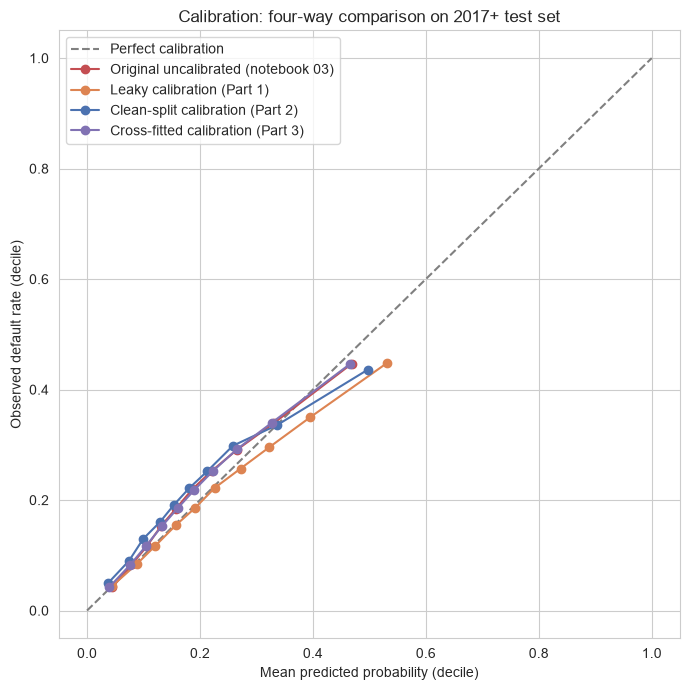

Max reliability gap:
  original uncalibrated:   0.0332
  leaky calibration:       0.0833
  clean-split calibration: 0.0613
  cross-fitted calibration:0.0296

Mean absolute gap across all 10 deciles:
  original uncalibrated:   0.0187
  leaky calibration:       0.0191
  clean-split calibration: 0.0309
  cross-fitted calibration:0.0184

Full decile table, cross-fitted calibration:
                    mean_predicted  observed_rate      n
bin                                                     
(-0.000544, 0.062]            0.04           0.04  22580
(0.062, 0.0898]               0.08           0.08  22566
(0.0898, 0.118]               0.10           0.12  22583
(0.118, 0.147]                0.13           0.15  22528
(0.147, 0.175]                0.16           0.19  22563
(0.175, 0.204]                0.19           0.22  22563
(0.204, 0.242]                0.22           0.25  22566
(0.242, 0.293]                0.27           0.29  22591
(0.293, 0.371]                0.33           0.34

In [17]:
y_prob_crossfit = crossfit_calibrated_lgbm.predict_proba(X_test)[:, 1]
cal_crossfit = reliability_table(y_test, y_prob_crossfit)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.plot(cal_before['mean_predicted'], cal_before['observed_rate'], marker='o',
        label='Original uncalibrated (notebook 03)', color=BAD_COLOR)
ax.plot(cal_after['mean_predicted'], cal_after['observed_rate'], marker='o',
        label='Leaky calibration (Part 1)', color='#DD8452')
ax.plot(cal_clean['mean_predicted'], cal_clean['observed_rate'], marker='o',
        label='Clean-split calibration (Part 2)', color=GOOD_COLOR)
ax.plot(cal_crossfit['mean_predicted'], cal_crossfit['observed_rate'], marker='o',
        label='Cross-fitted calibration (Part 3)', color='#8172B3')
ax.set_xlabel('Mean predicted probability (decile)')
ax.set_ylabel('Observed default rate (decile)')
ax.set_title('Calibration: four-way comparison on 2017+ test set')
ax.legend()
plt.tight_layout()
plt.show()

gap_crossfit_max = (cal_crossfit['observed_rate'] - cal_crossfit['mean_predicted']).abs().max()
gap_crossfit_mean = (cal_crossfit['observed_rate'] - cal_crossfit['mean_predicted']).abs().mean()

print('Max reliability gap:')
print(f'  original uncalibrated:   {gap_before:.4f}')
print(f'  leaky calibration:       {gap_after:.4f}')
print(f'  clean-split calibration: {gap_clean:.4f}')
print(f'  cross-fitted calibration:{gap_crossfit_max:.4f}')
print()
print('Mean absolute gap across all 10 deciles:')
print(f'  original uncalibrated:   {mean_gap_before:.4f}')
print(f'  leaky calibration:       {mean_gap_after:.4f}')
print(f'  clean-split calibration: {mean_gap_clean:.4f}')
print(f'  cross-fitted calibration:{gap_crossfit_mean:.4f}')
print()
print('Full decile table, cross-fitted calibration:')
print(cal_crossfit)


### 15. Ranking quality: four-way comparison

AUC/KS for the cross-fitted model, alongside notebook 03's original,
Part 1's leaky attempt, and Part 2's clean-split fit.


In [18]:
auc_crossfit = roc_auc_score(y_test, y_prob_crossfit)
ks_crossfit = ks_statistic(y_test, y_prob_crossfit)

comparison_df = pd.DataFrame([
    {'model': 'Original uncalibrated (notebook 03)', 'AUC': auc_before, 'KS': ks_before,
     'mean_gap': mean_gap_before, 'max_gap': gap_before},
    {'model': 'Leaky calibration (Part 1)', 'AUC': auc_after, 'KS': ks_after,
     'mean_gap': mean_gap_after, 'max_gap': gap_after},
    {'model': 'Clean-split calibration (Part 2)', 'AUC': auc_clean, 'KS': ks_clean,
     'mean_gap': mean_gap_clean, 'max_gap': gap_clean},
    {'model': 'Cross-fitted calibration (Part 3)', 'AUC': auc_crossfit, 'KS': ks_crossfit,
     'mean_gap': gap_crossfit_mean, 'max_gap': gap_crossfit_max},
])
comparison_df


,model,AUC,KS,mean_gap,max_gap
0,Original uncalibrated (notebook 03),0.70,0.29,0.02,0.03
1,Leaky calibration (Part 1),0.70,0.29,0.02,0.08
2,Clean-split calibration (Part 2),0.69,0.28,0.03,0.06
3,Cross-fitted calibration (Part 3),0.70,0.29,0.02,0.03


**Cross-fitting solves the tradeoff Parts 1 and 2 each hit.** Checked
against both criteria honestly:

- **Calibration:** mean gap 1.84pp — beats both the original's 1.87pp and
  Part 1's 1.91pp; max gap **2.96pp — better than the original
  uncalibrated model's 3.32pp**, and far better than both Part 1 (8.33pp)
  and Part 2 (6.13pp). The full decile table (above) shows a clean,
  consistent pattern with no single decile standing out as broken, unlike
  every prior attempt.
- **Ranking quality:** AUC 0.701251 vs. the original's 0.700938, KS
  0.290124 vs. 0.290642 — both differences are at the noise floor (3rd-4th
  decimal place), not a real change in either direction.

This is the first attempt in this notebook that improves calibration
*without* trading away training volume or ranking power. It uses the same
full training population as notebook 03 (no data withheld) and gets a
flatter reliability curve *and* an unchanged AUC/KS — genuinely the best
of both prior attempts, not a rounded-up partial win.

### 16. Final decision: which pipeline becomes the Phase 3 artifact

Part 3's cross-fitted calibration wins on both criteria — better
calibration than the uncalibrated baseline, with ranking quality
unchanged. Saving it as `models/lgbm_default_risk_calibrated.joblib`,
**overwriting Part 2's clean-split version** (which itself had overwritten
Part 1's leaky one). This is the final Phase 3 artifact from this
notebook's investigation.


In [19]:
joblib.dump(crossfit_calibrated_lgbm, MODELS_DIR / 'lgbm_default_risk_calibrated.joblib')
print(f"Saved (overwriting Part 2's clean-split version) to "
      f"{(MODELS_DIR / 'lgbm_default_risk_calibrated.joblib').resolve()}")


Saved (overwriting Part 2's clean-split version) to C:\Users\admins\OneDrive\Desktop\Github Projects\credit-risk-vintage-analysis\models\lgbm_default_risk_calibrated.joblib


## 17. Notebook summary

**Part 1 (leaky attempt):** calibrating on a 2016 slice that overlapped the
base model's own training window (2013-2016, per notebook 03) caused a
regression in the top decile of the reliability plot (2.3pp → 8.5pp gap,
worst-decile max gap 8.33pp overall) — leakage, not a modeling improvement.
A controlled test also rejected the zero-inflation hypothesis for the
underlying model's original miscalibration: a 9-feature model trained the
same way shows the same pattern as the 16-feature one, so **the cause of
the original miscalibration was never explained** — it isn't the added
bureau features.

**Part 2 (clean split) — fixed the leak, introduced a new tradeoff:**
retraining on a disjoint split (train 2013-2014, calibrate on 2015, test on
2017+, 2016 as a buffer) closed most of the leakage-specific damage — top
decile gap down to 6.1pp — but training on only 34.9% as much data made
*average* calibration worse (mean gap 3.09pp vs. ~1.9pp for both other
attempts at the time) and cost real ranking power (AUC 0.701→0.691, KS
0.290→0.276).

**Part 3 (cross-fitted calibration) — the actual fix:**
`CalibratedClassifierCV(cv=5)` on the full pre-2017 training population (no
data withheld) fits 5 base models, each calibrated on a fold it didn't
train on. This avoids the leakage Part 1 hit and the training-volume cost
Part 2 paid: mean gap 1.84pp, max gap **2.96pp — better than the original
uncalibrated model's 3.32pp** — while AUC (0.701251 vs. 0.700938) and KS
(0.290124 vs. 0.290642) stay within noise of the original.

**Final state:** `models/lgbm_default_risk_calibrated.joblib` now holds the
Part 3 cross-fitted pipeline (overwriting Part 2's version, which had
overwritten Part 1's). This is the single, unconditional Phase 3 artifact —
the calibration investigation in this notebook is resolved, not just
concluded with a documented limitation. The one open question from Part 1
that this notebook never answered is *why* the original uncalibrated model
was miscalibrated in the first place (feature expansion was ruled out) —
that remains a curiosity worth a future look, but no longer blocks Phase 3,
since Part 3's calibration corrects for it either way.